# Loading Libraries and Packages

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler

# Phase 5: Policy Gradient Theorem (Air Quality RL)

## Loading Data

In [10]:
df = pd.read_csv('../Data/delhi_aqi.csv')
df['date'] = pd.to_datetime(df['date'])
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.dayofyear
df['month'] = df['date'].dt.month

# Cyclical encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)

df['day_sin'] = np.sin(2 * np.pi * df['day'] / 365.25)
df['day_cos'] = np.cos(2 * np.pi * df['day'] / 365.25)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)

# Extract PM2.5 BEFORE dropping columns
y = df['pm2_5'].values  # Ensure column name matches dataset

df = df.drop(columns=['date', 'hour', 'day', 'month', 'pm2_5'])

train_len = int(0.7 * len(df))
test_len = int(0.15 * len(df))
val_len = len(df) - train_len - test_len

X_train_df = df[:train_len]
X_val_df = df[train_len:train_len+val_len]
X_test_df = df[train_len+val_len:]

y_train = y[:train_len]
y_val = y[train_len:train_len+val_len]
y_test = y[train_len+val_len:]

# Standard Scaling
scaler = StandardScaler()
X_train_total = scaler.fit_transform(X_train_df)
X_val_total = scaler.transform(X_val_df)
X_test_total = scaler.transform(X_test_df)

## Model Class

In [11]:
class AirQualityEnv:
    def __init__(self, features, pm25_targets, window_size=24, episode_length=168):
        self.features = features
        self.targets = pm25_targets
        self.window_size = window_size
        self.episode_length = episode_length
        
        self.n_features = features.shape[1]
        self.state_dim = self.window_size * self.n_features
        
        self.current_step = 0
        self.start_idx = 0

    def reset(self):
        max_start = len(self.features) - self.window_size - self.episode_length - 1
        self.start_idx = np.random.randint(0, max_start)
        self.current_step = 0
        return self._get_state()

    def _get_state(self):
        idx = self.start_idx + self.current_step
        return self.features[idx : idx + self.window_size].flatten()

    def step(self, action):
        idx = self.start_idx + self.current_step + self.window_size
        actual_pm25 = self.targets[idx + 1]
        
        if action == 1:
            reward = -0.1
        else:
            reward = -10.0 if actual_pm25 > 150 else 0.0
                
        self.current_step += 1
        done = self.current_step >= self.episode_length
        
        next_state = self._get_state() if not done else None
        return next_state, reward, done


class PolicyNetwork(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.net(x)

## REINFORCE Algorithm

In [12]:
def train_reinforce(env, policy_net, num_episodes=500, gamma=0.99, lr=1e-3):
    optimizer = optim.Adam(policy_net.parameters(), lr=lr)
    returns_history = []
    
    for episode in range(num_episodes):
        state = env.reset()
        log_probs = []
        rewards = []
        
        done = False
        while not done:
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            
            prob_on = policy_net(state_tensor)
            prob_on = torch.clamp(prob_on, 1e-6, 1 - 1e-6)
            
            m = torch.distributions.Bernoulli(prob_on)
            action = m.sample()
            log_prob = m.log_prob(action).squeeze()
            
            next_state, reward, done = env.step(int(action.item()))
            
            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state
            
        # Compute returns
        G = np.zeros(len(rewards), dtype=np.float32)
        cumulative = 0
        
        for t in reversed(range(len(rewards))):
            cumulative = rewards[t] + gamma * cumulative
            G[t] = cumulative
            
        G = torch.tensor(G)
        G = (G - G.mean()) / (G.std() + 1e-8)
        
        # Policy loss
        loss = 0.0
        for log_p, g in zip(log_probs, G):
            loss += -log_p * g
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_reward = sum(rewards)
        returns_history.append(total_reward)
        
        if (episode + 1) % 50 == 0:
            print(f"Episode {episode+1} | Return: {total_reward:.2f}")
    
    return returns_history

## Driver Code

In [13]:
env = AirQualityEnv(
    features=X_train_total,
    pm25_targets=y_train,
    window_size=24,
    episode_length=168
)

policy = PolicyNetwork(input_dim=env.state_dim)

print("Starting training...")
returns = train_reinforce(env, policy)

Starting training...
Episode 50 | Return: -52.80
Episode 100 | Return: -16.80
Episode 150 | Return: -16.80
Episode 200 | Return: -16.80
Episode 250 | Return: -16.80
Episode 300 | Return: -16.80
Episode 350 | Return: -16.80
Episode 400 | Return: -16.80
Episode 450 | Return: -16.80
Episode 500 | Return: -16.80


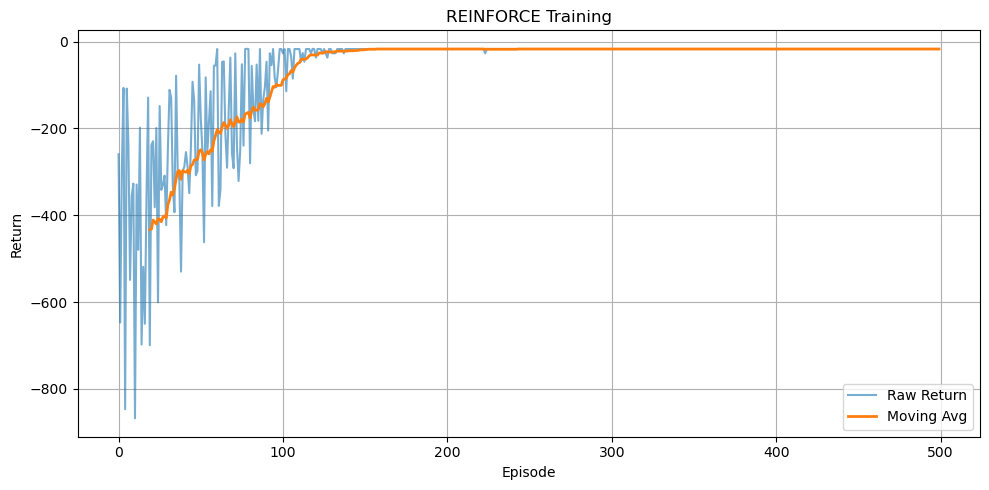

In [14]:
plt.figure(figsize=(10,5))
plt.plot(returns, alpha=0.6, label='Raw Return')

moving_avg = np.convolve(returns, np.ones(20)/20, mode='valid')
plt.plot(range(19, len(returns)), moving_avg, linewidth=2, label='Moving Avg')

plt.title("REINFORCE Training")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("../Report/5_13.png", dpi = 300)
plt.show()